# Ejercicios de práctica — Regresión

Tres ejercicios para repasar lo de la sesión durante el fin de semana. Puedes apoyarte en el notebook de clase como referencia siempre que lo necesites.

**Cómo trabajarlos**
- Ejecuta primero la celda de *Preparación*.
- En cada ejercicio tienes los datos ya creados y una celda en blanco para tu código.

Trabaja a tu ritmo: lo importante es entender cada paso, no terminar rápido.


In [1]:
# Preparación: ejecuta esta celda antes de empezar. Añade #pip install numpy pandas matplotlib scikit-learn si no tienes estas librerías instaladas.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Ejercicio 1 — Horas de estudio y nota del examen

Tenemos las horas que estudia cada alumno a la semana y la nota que sacó. Queremos predecir la **nota** a partir de las **horas de estudio**.

**Lo que tienes que hacer:**
1. Echa un vistazo a los datos (`.head()`, `.describe()`) y haz un *scatter* de horas vs nota.
2. Entrena una regresión lineal simple (`X` = horas, `y` = nota).
3. Dibuja la recta del modelo sobre los puntos.
4. ¿Cuánto sube la nota por cada hora extra de estudio? (mira la pendiente con `.coef_`).
5. Calcula **MAE, RMSE y R²**.
6. ¿Qué nota predice el modelo para alguien que estudia **8 horas**?



In [2]:
# Datos del Ejercicio 1 (ejecuta esta celda)
rng = np.random.default_rng(0)
n = 120
horas = rng.uniform(0, 15, n).round(1)
nota = (2 + 0.55*horas + rng.normal(0, 1.2, n)).clip(0, 10).round(1)
datos = pd.DataFrame({"horas_estudio": horas, "nota": nota})
datos.head(3)


,horas_estudio,nota
0,9.6,8.3
1,4.0,5.6
2,0.6,3.3


In [3]:
datos.tail(3)

,horas_estudio,nota
117,1.0,1.1
118,12.6,6.8
119,1.0,1.4


In [4]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   horas_estudio  120 non-null    float64
 1   nota           120 non-null    float64
dtypes: float64(2)
memory usage: 2.0 KB


In [5]:
datos.describe().T

,count,mean,std,min,25%,50%,75%,max
horas_estudio,120.0,8.095000,4.629806,0.0,4.375,8.65,12.20,15.0
nota,120.0,6.279167,2.596180,0.0,4.500,6.80,8.15,10.0


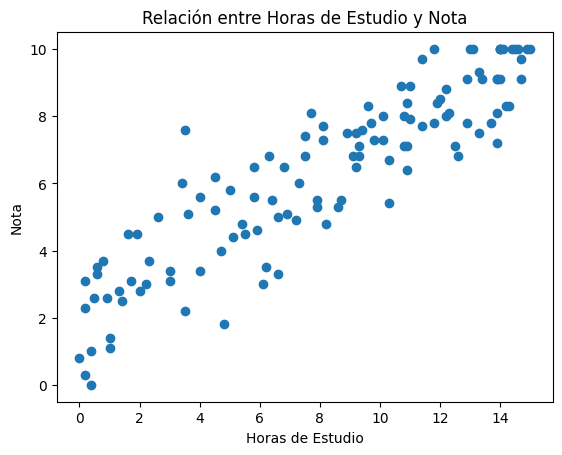

In [6]:
# Tu código del Ejercicio 1
datos.describe()
plt.scatter(datos["horas_estudio"], datos["nota"])
plt.xlabel("Horas de Estudio")
plt.ylabel("Nota")
plt.title("Relación entre Horas de Estudio y Nota")
plt.show()

Pendiente (coeficiente): 0.5031872298037926
Intercept: 2.189556527770641


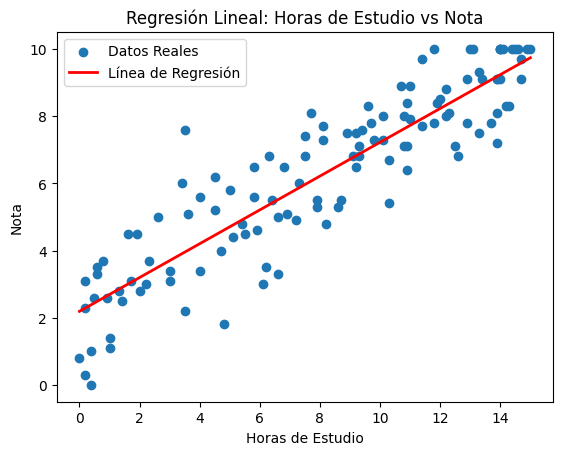

In [7]:
# modelo de regresión simple
#  X = tabla con solo la columna "horas_estudio" (variable independiente)
X = datos[["horas_estudio"]] # X debe ser un DataFrame, no una Serie, por eso usamos doble corchete

# Y = la columna "nota" (variable dependiente, objetivo)
y = datos["nota"] # y puede ser una Serie, por eso usamos un solo corchete, 
# aunque también podríamos usar doble corchete y quedaría como DataFrame de una sola columna, 
# pero lo común es dejarlo como Serie para la variable objetivo

# Dividimos los datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creamos el modelo de regresión lineal
modelo = LinearRegression() 

# Entrenamos el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

# Hacemos predicciones con el modelo usando los datos de prueba
y_pred = modelo.predict(X_test)

# El coeficiente de la variable "horas_estudio", que indica cuánto cambia la "nota" por cada hora adicional 
# de estudio
print(f"Pendiente (coeficiente): {modelo.coef_[0]}")
 
# La ordenada al origen (intercepto), el valor de "nota" cuando "horas_estudio" es 0 según el modelo 
print(f"Intercept: {modelo.intercept_}")

# Para visualizar la línea de regresión, generamos valores de "horas_estudio" y sus correspondientes 
# predicciones de "nota"
xs = np.linspace(X["horas_estudio"].min(), X["horas_estudio"].max(), 100)  
x_line = pd.DataFrame({"horas_estudio": xs}) # Creamos un DataFrame con la columna "horas_estudio" para usarlo en la predicción
ys = modelo.predict(x_line) # Obtenemos las predicciones de "nota" para cada valor de "horas_estudio"

# Graficamos los puntos de datos y la línea de regresión
plt.scatter(X["horas_estudio"], y, label="Datos Reales")
plt.plot(xs, ys, color="red", linewidth=2, label="Línea de Regresión")
plt.xlabel("Horas de Estudio")
plt.ylabel("Nota")
plt.title("Regresión Lineal: Horas de Estudio vs Nota")
plt.legend()
plt.show()

In [8]:
# El enfoque matemático con predicciones manual
# 1. Guardamos los coeficientes en variables limpias
pendiente = modelo.coef_[0]
intercepcion = modelo.intercept_

# 2. Creamos una lista de valores X cualquiera
valores_x = [1, 2, 3, 4, 5, 7, 8]

# 3. Calculamos la Y manualmente usando la ecuación de la recta
predicciones_manuales = []
for x in valores_x:
    y = (pendiente * x) + intercepcion  # <- Aquí aplicas Y = mX + b
    predicciones_manuales.append(y)

# 4. Creamos la tabla comparativa
tabla_predicciones = pd.DataFrame({
    "Ingreso (X)": valores_x,
    "Valor Casa Predicho (Y)": predicciones_manuales
})
print(tabla_predicciones)

   Ingreso (X)  Valor Casa Predicho (Y)
0            1                 2.692744
1            2                 3.195931
2            3                 3.699118
3            4                 4.202305
4            5                 4.705493
5            7                 5.711867
6            8                 6.215054


In [9]:
# Para verificar que las predicciones manuales coinciden con las del modelo, podemos usar el método predict 
# del modelo -> modelo.predict(x_line)

# 1. Definimos los valores de X que nos interesa evaluar
nuevos_x = pd.DataFrame({"horas_estudio": [1, 2, 3, 4, 5, 7, 8]})

# 2. Dejamos que el modelo calcule las Y de forma eficiente
nuevos_x["Prediccion_Nota"] = modelo.predict(nuevos_x)

# 3. Mostramos la tabla resultante
print(nuevos_x)

   horas_estudio  Prediccion_Nota
0              1         2.692744
1              2         3.195931
2              3         3.699118
3              4         4.202305
4              5         4.705493
5              7         5.711867
6              8         6.215054


### Regla de ORO
La pendiente siempre responde a la pregunta: "Si la variable $X$ aumenta en una unidad, ¿cuánto cambia la variable $Y$?"

In [10]:
# Evaluamos el modelo con métricas de regresión
mae = mean_absolute_error(y_test, y_pred)  # error absoluto medio
mse = mean_squared_error(y_test, y_pred)  # error cuadrático medio
rmse = np.sqrt(mse)  # raíz del error cuadrático medio (misma unidad que Y)
r2 = r2_score(y_test, y_pred)  # R² (coeficiente de determinación)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.6689709423318243
MSE: 0.6865712841577828
RMSE: 0.8285959716036416
R²: 0.8873623777966412


1. MAE (Error Absoluto Medio): 0.66
- El MAE es la métrica más intuitiva de todas porque se mide en la misma unidad que tu variable Y (en este caso, puntos de la nota).
- Significado: En promedio, las predicciones de tu modelo fallan por 0.66 puntos respecto a la nota real.- Ejemplo: Si el modelo predice que un alumno sacará un 7.5, en la realidad ese alumno probablemente obtuvo entre un 6.84 (7.5 - 0.66) o un 8.16 (7.5 + 0.66). Es un error bastante bajo, lo cual es muy bueno.
- 2. MSE (Error Cuadrático Medio): 0.68
- El MSE hace algo peculiar: toma la distancia de cada error, la eleva al cuadrado, y luego saca el promedio de todos esos cuadrados.
- Significado: Al elevar al cuadrado, las unidades se vuelven "puntos al cuadrado" (lo cual no tiene mucho sentido físico en la vida real).
- ¿Para qué sirve entonces?: Su gran utilidad es que castiga con mucha dureza los errores grandes. Si el modelo se equivoca por 1 punto, el castigo es 1^2 = 1. Pero si se equivoca en un alumno por 4 puntos, el castigo es 4^2 = 16. Un MSE de 0.68 (cercano al MAE) te indica que no tienes valores atípicos (outliers); es decir, el modelo no cometió fallos catastróficos con ningún estudiante en el grupo de prueba.
- 3. RMSE (Raíz del Error Cuadrático Medio): 0.82
- Como el MSE nos dejaba las unidades "al cuadrado", el RMSE viene al rescate aplicándole una raíz cuadrada al MSE (sqrt{0.686} = 0.82). Esto devuelve el error a la unidad original (puntos de nota).
- Significado: Es otra forma de medir el error promedio, pero con una sensibilidad especial. Al igual que el MSE, el RMSE siempre será un poco más alto que el MAE si existen errores grandes aislados.
- Interpretación: Tu error promedio "penalizado" es de 0.82 puntos. Sigue siendo un excelente indicador de que el modelo es bastante preciso.
- 4. R^2 (Coeficiente de Determinación): 0.887
- Esta es la métrica estrella para saber el éxito global del modelo. No se mide en notas, sino que es un porcentaje (va de 0 a 1, donde 1 es la perfección absoluta).
- Significado: Tu R^2 es de 0.887, lo que equivale a un 88.7%.
- Interpretación técnica: El 88.7% de la variación en las notas de los estudiantes se puede explicar y predecir directamente por la cantidad de horas que pasaron estudiando. El otro 11.3% restante se debe a factores que tu modelo no conoce (como si el alumno durmió bien, su nivel de estrés, o si el examen estaba difícil).

In [11]:
# 1. Creamos el DataFrame con los 5 primeros valores reales y predichos
tabla_errores = pd.DataFrame({
    "Nota Real (y_test)": y_test.head(5).values,
    "Nota Predicha (y_pred)": y_pred[:5]
})

# 2. Calculamos el Error Absoluto (la diferencia directa)
tabla_errores["Error (Diferencia)"] = tabla_errores["Nota Real (y_test)"] - tabla_errores["Nota Predicha (y_pred)"]

# 3. Calculamos el Error Absoluto (sin signos negativos)
tabla_errores["Error Absoluto"] = tabla_errores["Error (Diferencia)"].abs()

# 4. NUEVO: Calculamos el Error Cuadrático (elevado al cuadrado)
# Multiplicamos el error por sí mismo para eliminar los signos y magnificar fallos grandes
tabla_errores["Error Cuadrado"] = tabla_errores["Error (Diferencia)"] ** 2

# 5. Mostramos la tabla resultante formateada a 3 decimales para apreciar bien los cuadrados
print(tabla_errores.round(3))

   Nota Real (y_test)  Nota Predicha (y_pred)  Error (Diferencia)  \
0                 4.6                   5.158              -0.558   
1                 7.1                   6.869               0.231   
2                 8.8                   8.328               0.472   
3                 3.7                   3.347               0.353   
4                10.0                   9.737               0.263   

   Error Absoluto  Error Cuadrado  
0           0.558           0.312  
1           0.231           0.053  
2           0.472           0.222  
3           0.353           0.125  
4           0.263           0.069  


## Ejercicio 2 — Precio del alquiler de un piso

Para varios pisos tenemos su superficie (m²), número de habitaciones y antigüedad (años), y el alquiler mensual (€). Queremos predecir el **alquiler**.

**Lo que tienes que hacer:**
1. Explora los datos.
2. Separa en **train y test** (`test_size=0.2`, `random_state=42`).
3. Entrena una regresión múltiple con las **tres** variables.
4. Calcula el **R² sobre el test**.
5. Mira los **coeficientes**: ¿qué variables suben el alquiler y cuál lo baja? ¿Tiene sentido?
6. Entrena ahora usando **solo la superficie** y compara el R². ¿Cuánto se pierde?
7. Predice el alquiler de un piso de **80 m², 3 habitaciones y 10 años**.



In [12]:
# Datos del Ejercicio 2 (ejecuta esta celda)
rng = np.random.default_rng(1)
n = 300
superficie = rng.integers(30, 150, n)
habitaciones = rng.integers(1, 5, n)
antiguedad = rng.integers(0, 50, n)
alquiler = (200 + 8*superficie + 50*habitaciones - 3*antiguedad + rng.normal(0, 80, n)).round(0)
pisos = pd.DataFrame({"superficie": superficie, "habitaciones": habitaciones,
                      "antiguedad": antiguedad, "alquiler": alquiler})
pisos.head()


,superficie,habitaciones,antiguedad,alquiler
0,86,1,45,872.0
1,91,4,13,1118.0
2,120,2,22,1160.0
3,144,2,27,1375.0
4,34,3,24,621.0


In [13]:
pisos.tail(3)

,superficie,habitaciones,antiguedad,alquiler
297,93,1,42,818.0
298,139,3,39,1303.0
299,47,1,11,506.0


In [14]:
pisos.info()    

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   superficie    300 non-null    int64  
 1   habitaciones  300 non-null    int64  
 2   antiguedad    300 non-null    int64  
 3   alquiler      300 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 9.5 KB


In [15]:
pisos.describe().T

,count,mean,std,min,25%,50%,75%,max
superficie,300.0,91.146667,34.310677,30.0,62.0,90.0,122.00,149.0
habitaciones,300.0,2.486667,1.134657,1.0,1.0,2.0,4.00,4.0
antiguedad,300.0,23.940000,14.083711,0.0,12.0,23.0,35.00,49.0
alquiler,300.0,978.190000,291.687113,257.0,751.0,972.0,1242.25,1659.0


In [16]:
X = pisos[["superficie", "habitaciones", "antiguedad"]]
y = pisos["alquiler"]

# Dividimos los datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

coeficientes = pd.Series(modelo.coef_, index=X.columns).sort_values(ascending=False)

print("Coeficientes del modelo: ")
print(coeficientes)

print("R²:", r2_score(y_test, modelo.predict(X_test)))


Coeficientes del modelo: 
habitaciones    51.642881
superficie       8.026226
antiguedad      -2.726753
dtype: float64
R²: 0.9028983661380835


In [17]:
# Predicimos el valor del alquiler para un piso con superficie de 80 m², 3 habitaciones y antigüedad de 10 años
nuevo_piso = pd.DataFrame({"superficie": [80], "habitaciones": [3], "antiguedad": [10]})

predicciones = modelo.predict(nuevo_piso)
print("Predicción de alquiler para el nuevo piso:", predicciones[0].round(2))

Predicción de alquiler para el nuevo piso: 954.9


In [18]:
# tomamos encuenta solamente la superficie para predecir el alquiler
X = pisos[["superficie"]]
y = pisos["alquiler"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_superficie = LinearRegression()
modelo_superficie.fit(X_train, y_train)

coef_superficie = modelo_superficie.coef_[0]
print("Coeficiente de superficie:", coef_superficie)

print("R2", r2_score(y_test, modelo_superficie.predict(X_test)))

Coeficiente de superficie: 7.916098757396269
R2 0.8428576135697743


In [19]:
prediccion_superficie = modelo_superficie.predict(nuevo_piso[["superficie"]])
print("Predicción de alquiler usando solo superficie:", prediccion_superficie[0].round(2))

Predicción de alquiler usando solo superficie: 892.19


In [20]:
from sklearn.preprocessing import PolynomialFeatures  
from sklearn.pipeline import make_pipeline   
X = pisos[["superficie"]]

Y = pisos["alquiler"]

# train_test_split -> divide los datos en 2 partes: una para entrenar el modelo (train) y otra para evaluarlo (test).
# test_size=0.2 -> el 20% de los datos se usan para test y el 80% para train.
# random_state=42 -> fija la semilla del generador de números aleatorios para que la división sea siempre la misma (reproducible).
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Entrenamos el modelo con los datos de train.
for grado in [1, 2, 5, 15]:
    # PolynomialFeatures(grado) -> crea nuevas columnas con x², x³... hasta el grado indicado.
    # make_pipeline -> encadena PolynomialFeatures y LinearRegression en un solo objeto.Primero transforma
    #  y luego ajusta la regresión lineal.
    modelo_superficie = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    modelo_superficie.fit(X_train, y_train)
   
    # medir el R² en train y test para cada grado
    r2_tr = r2_score(y_train, modelo_superficie.predict(X_train))
    r2_ts = r2_score(y_test, modelo_superficie.predict(X_test))

    # grado:>2 -> muestra el grado con al menos 2 dígitos (para que quede alineado)
    print(f"Grado {grado:>2}: R² train = {r2_tr:.4f}, R² test = {r2_ts:.4f}")

Grado  1: R² train = 0.8594, R² test = 0.8429
Grado  2: R² train = 0.8596, R² test = 0.8447
Grado  5: R² train = 0.8638, R² test = 0.8296
Grado 15: R² train = 0.8260, R² test = 0.8249


## Ejercicio 3 — Publicidad y ventas

Una tienda online registra cuánto gasta en publicidad en redes sociales y en TV (en €) y las ventas (€) que consigue. Queremos predecir las **ventas** y, de paso, ver **qué canal rinde más por cada euro invertido**.

**Lo que tienes que hacer:**
1. Explora los datos y sepáralos en train/test (`test_size=0.2`, `random_state=42`).
2. Entrena una regresión múltiple y evalúa **MAE, RMSE y R² sobre el test**.
3. Compara el **R² en train** con el **R² en test**: ¿el modelo generaliza bien o se ha "aprendido" los datos de memoria?
4. Mira los coeficientes de `pub_redes` y `pub_tv`. Como **ambos están en euros**, aquí sí se pueden comparar directamente: ¿qué canal da más ventas por euro?
5. Predice las ventas con un presupuesto de **500 € en redes y 1.000 € en TV**.




In [21]:
# Datos del Ejercicio 3 (ejecuta esta celda)
rng = np.random.default_rng(2)
n = 250
pub_redes = rng.integers(0, 1000, n)
pub_tv = rng.integers(0, 2000, n)
ventas = (500 + 4*pub_redes + 2.5*pub_tv + rng.normal(0, 600, n)).round(0)
mkt = pd.DataFrame({"pub_redes": pub_redes, "pub_tv": pub_tv, "ventas": ventas})
mkt.head()


,pub_redes,pub_tv,ventas
0,837,1193,7336.0
1,261,1609,5059.0
2,109,1774,4630.0
3,298,1648,4746.0
4,413,1506,5716.0


In [23]:
# ultimas filas
mkt.tail(3)


,pub_redes,pub_tv,ventas
247,385,514,3107.0
248,511,1898,6544.0
249,446,318,3455.0


In [24]:
mkt.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pub_redes  250 non-null    int64  
 1   pub_tv     250 non-null    int64  
 2   ventas     250 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 6.0 KB


In [26]:
mkt.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
pub_redes,250.0,503.75,290.45,3.0,254.75,504.5,768.00,999.0
pub_tv,250.0,1015.05,588.94,4.0,474.75,1048.0,1540.50,1988.0
ventas,250.0,5001.20,2006.32,662.0,3455.00,4899.5,6562.75,10876.0


In [27]:
X = mkt[["pub_redes", "pub_tv"]] # las variables independientes son "pub_redes" y "pub_tv", que usaremos para predecir "ventas"
y = mkt["ventas"] # la variable objetivo es "ventas", que queremos predecir a partir de las variables independientes "pub_redes" y "pub_tv" 

# Dividimos los datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creamos el modelo de regresión lineal
modelo_mkt = LinearRegression()

# Entrenamos el modelo con los datos de entrenamiento
modelo_mkt.fit(X_train, y_train)

# Obtenemos los coeficientes del modelo para cada variable independiente
coeficientes_mkt = pd.Series(modelo_mkt.coef_, index=X.columns).sort_values(ascending=False)
print("Coeficientes del modelo de marketing: ")
print(coeficientes_mkt)

# Evaluamos el modelo con R², que indica qué porcentaje de la variabilidad de las ventas se explica por 
# las variables de publicidad
print("R²:", r2_score(y_test, modelo_mkt.predict(X_test)))


Coeficientes del modelo de marketing: 
pub_redes    4.374623
pub_tv       2.505119
dtype: float64
R²: 0.8819447025642532


Los coeficientes indican cuánto aumentan las ventas por cada unidad adicional que inviertas en ese canal de publicidad, manteniendo todo lo demás constante.

- pub_redes (4.37): Por cada euro (o unidad monetaria) invertido en publicidad en redes sociales, las ventas aumentan en 4.37 unidades. Es el canal más rentable.

- pub_tv (2.51): Por cada euro invertido en publicidad en televisión, las ventas aumentan en 2.51 unidades.

In [31]:
# evaluamos el modelo con métricas de regresión
mae_mkt = mean_absolute_error(y_test, modelo_mkt.predict(X_test)) # error absoluto medio, la diferencia promedio entre las ventas reales y las predichas por el modelo
mse_mkt = mean_squared_error(y_test, modelo_mkt.predict(X_test)) # error cuadrático medio, la diferencia promedio al cuadrado entre las ventas reales y las predichas por el modelo, penaliza más los errores grandes
rmse_mkt = np.sqrt(mse_mkt).round(2)
print("MAE:", mae_mkt)
print("MSE:", mse_mkt)
print("RMSE:", rmse_mkt)

MAE: 529.4956963002792
MSE: 465439.0685494076
RMSE: 682.23


Interpretación de las Métricas de Error y Ajuste
El Coeficiente de Determinación (R^2)
- R^2: 0.8819 (88.19%)
- Qué significa: El 88.2% de la variabilidad de las ventas se puede explicar y predecir utilizando únicamente la inversión en redes sociales y televisión. El 11.8% restante se debe al azar o a factores que no estás midiendo (como la competencia, la época del año, etc.). Un R^2 superior al 80% suele considerarse un excelente ajuste en marketing.

Métricas de Error (MAE, MSE, RMSE)
Estas métricas miden "qué tan lejos" se quedan las predicciones del modelo respecto a las ventas reales.

MAE (Error Absoluto Medio): 529.50

En promedio, las predicciones del modelo fallan por unas 529.50 unidades de venta (ya sea por exceso o por defecto). Es fácil de entender porque está en las mismas unidades que tus ventas.

RMSE (Raíz del Error Cuadrático Medio): 682.23

También mide el error promedio, pero penaliza más los errores grandes. Como el RMSE (682.23) es notablemente mayor que el MAE (529.50), significa que el modelo comete algunos errores grandes puntuales (valores atípicos o outliers) en el conjunto de prueba.

MSE (Error Cuadrático Medio): 465,439.07

Es el RMSE al cuadrado. Matemáticamente es útil para entrenar el modelo, pero no es intuitivo de interpretar directamente porque sus unidades están al cuadrado (ventas al cuadrado).

In [32]:
# Predicimos las ventas para una campaña con 300 en publicidad en redes sociales y 1500 en publicidad en TV
nueva_campaña = pd.DataFrame({"pub_redes": [300], "pub_tv": [1500]})
prediccion_ventas = modelo_mkt.predict(nueva_campaña)   
print("Predicción de ventas para la nueva campaña:", prediccion_ventas[0].round(2))

Predicción de ventas para la nueva campaña: 5294.76


In [33]:
# Predicimos las ventas para una campaña con 500 en publicidad en redes sociales y 1000 en publicidad en TV
nueva_campaña = pd.DataFrame({"pub_redes": [500], "pub_tv": [1000]})
prediccion_ventas = modelo_mkt.predict(nueva_campaña)
print("Predicción de ventas para la nueva campaña:", prediccion_ventas[0].round(2))

Predicción de ventas para la nueva campaña: 4917.13
